# Olist data EDA

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import scipy.stats
import numpy as np
from plots import Plotter

### DB connection

In [2]:
conn = duckdb.connect('../data/olist.duckdb')

df = conn.execute("SELECT * FROM analytical_base_table").fetchdf()
df.head()

,order_id,customer_unique_id,customer_city,customer_state,order_purchase_timestamp,delivery_days,review_score,review_comment_message,price,freight_value,product_weight_g,product_category_name,seller_state,total_payment_value,max_installments,customer_lat,customer_lng,seller_lat,seller_lng
0,73fc7af87114b39712e6da79b0a377eb,68a5590b9926689be4e10f4ae2db21a8,osasco,SP,2018-01-11 15:30:49,6,4,NaN,185.00,13.63,1300,esporte_lazer,SP,397.26,8,-23.557079,-46.767579,-20.585751,-47.863693
1,a548910a1c6147796b98fdf73dbeba33,64190b91b656ab8f37eb89b93dc84584,nova odessa,SP,2018-02-28 12:25:19,9,5,NaN,79.79,8.30,245,informatica_acessorios,SP,88.09,1,-22.785779,-47.312537,-23.246681,-45.886909
2,f9e4b658b201a9f2ecdecbb34bed034b,1d47144362c14e94ccdd213e8ec277d5,santo antonio de jesus,BA,2018-02-03 09:56:22,13,5,NaN,149.00,45.12,6550,informatica_acessorios,MG,194.12,1,-12.967176,-39.243114,-20.940578,-45.827237
3,658677c97b385a9be170737859d3511b,c8cf6cb6b838dc7a33ed199b825e8616,gravatal,SC,2017-04-09 17:41:13,11,5,Recebi bem antes do prazo estipulado.,179.99,42.85,7650,ferramentas_jardim,MG,222.84,1,-28.328525,-49.049950,-20.940578,-45.827237
4,8e6bfb81e283fa7e4f11123a3fb894f1,d16000272660a1fef81482ad75ba572a,curitibanos,SC,2018-02-10 10:59:03,18,5,Parabéns lojas lannister adorei comprar pela I...,1199.00,134.25,9850,esporte_lazer,PR,1333.25,10,-27.290949,-50.577361,-25.508623,-49.226688


### Haversine formula

In [3]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in kilometers
    
    phi1, phi2 = map(np.radians, [lat1, lat2])
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)

    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

In [4]:
df['geo_distance_km'] = haversine_distance(df['customer_lat'], df['customer_lng'], df['seller_lat'], df['seller_lng'])

In [5]:
df.head()

,order_id,customer_unique_id,customer_city,customer_state,order_purchase_timestamp,delivery_days,review_score,review_comment_message,price,freight_value,product_weight_g,product_category_name,seller_state,total_payment_value,max_installments,customer_lat,customer_lng,seller_lat,seller_lng,geo_distance_km
0,73fc7af87114b39712e6da79b0a377eb,68a5590b9926689be4e10f4ae2db21a8,osasco,SP,2018-01-11 15:30:49,6,4,NaN,185.00,13.63,1300,esporte_lazer,SP,397.26,8,-23.557079,-46.767579,-20.585751,-47.863693,349.163739
1,a548910a1c6147796b98fdf73dbeba33,64190b91b656ab8f37eb89b93dc84584,nova odessa,SP,2018-02-28 12:25:19,9,5,NaN,79.79,8.30,245,informatica_acessorios,SP,88.09,1,-22.785779,-47.312537,-23.246681,-45.886909,154.641446
2,f9e4b658b201a9f2ecdecbb34bed034b,1d47144362c14e94ccdd213e8ec277d5,santo antonio de jesus,BA,2018-02-03 09:56:22,13,5,NaN,149.00,45.12,6550,informatica_acessorios,MG,194.12,1,-12.967176,-39.243114,-20.940578,-45.827237,1129.348471
3,658677c97b385a9be170737859d3511b,c8cf6cb6b838dc7a33ed199b825e8616,gravatal,SC,2017-04-09 17:41:13,11,5,Recebi bem antes do prazo estipulado.,179.99,42.85,7650,ferramentas_jardim,MG,222.84,1,-28.328525,-49.049950,-20.940578,-45.827237,883.585852
4,8e6bfb81e283fa7e4f11123a3fb894f1,d16000272660a1fef81482ad75ba572a,curitibanos,SC,2018-02-10 10:59:03,18,5,Parabéns lojas lannister adorei comprar pela I...,1199.00,134.25,9850,esporte_lazer,PR,1333.25,10,-27.290949,-50.577361,-25.508623,-49.226688,239.524332


## Distribution Plots

In [6]:
len(df[pd.isna(df.delivery_days)])

8

In [7]:
df = df.dropna(subset=['delivery_days'])

In [8]:
delivery_days = df.delivery_days.copy()

print(delivery_days.describe())

count     110832.0
mean     12.415268
std       9.449025
min            0.0
25%            7.0
50%           10.0
75%           16.0
max          210.0
Name: delivery_days, dtype: Float64


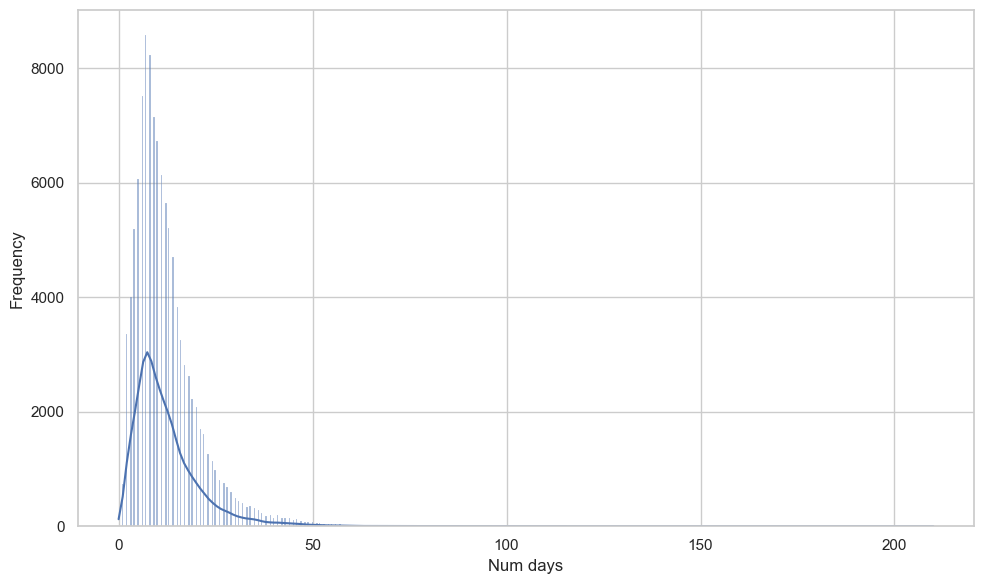

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Num days', ylabel='Frequency'>)

In [9]:
delivery_days_list = delivery_days.copy().tolist()

delivery_plot = Plotter()
delivery_plot.histogram(data=delivery_days_list, xlabel="Num days", ylabel="Frequency", show=True)

In [10]:
extream_delay = delivery_days[delivery_days > 100].copy()
high_delay = delivery_days[(delivery_days > 65) & (delivery_days < 100)].copy()

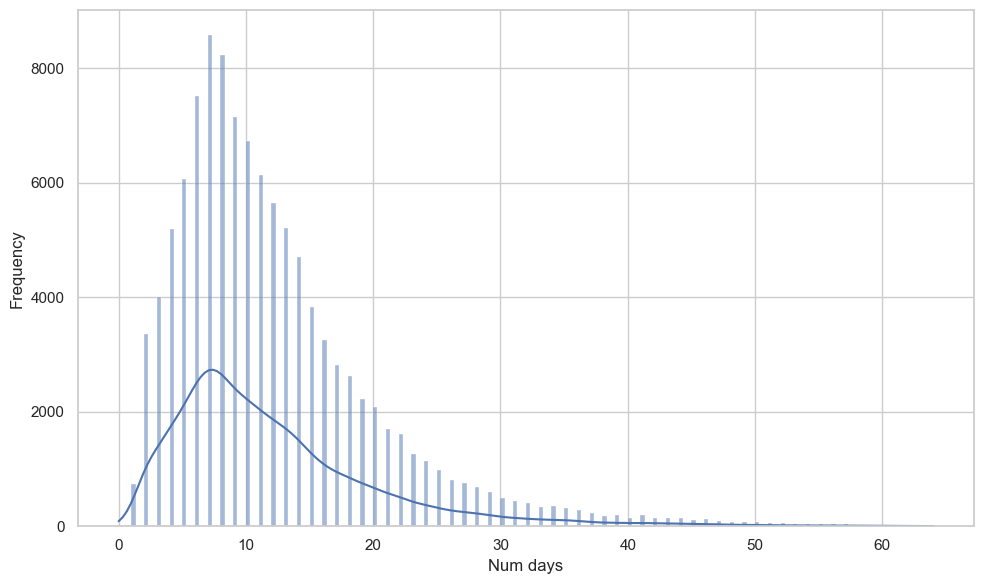

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Num days', ylabel='Frequency'>)

In [11]:
filtered_delivery_days_list = delivery_days[delivery_days < 65].copy().tolist()

delivery_plot.histogram(data=filtered_delivery_days_list, xlabel="Num days", ylabel="Frequency")

In [12]:
reviews = df.review_score.copy()

print(reviews.describe())

count    110005.0
mean     4.081278
std      1.347655
min           1.0
25%           4.0
50%           5.0
75%           5.0
max           5.0
Name: review_score, dtype: Float64


In [13]:
len(reviews[pd.isna(reviews)])

827

In [14]:
reviews = reviews.dropna()

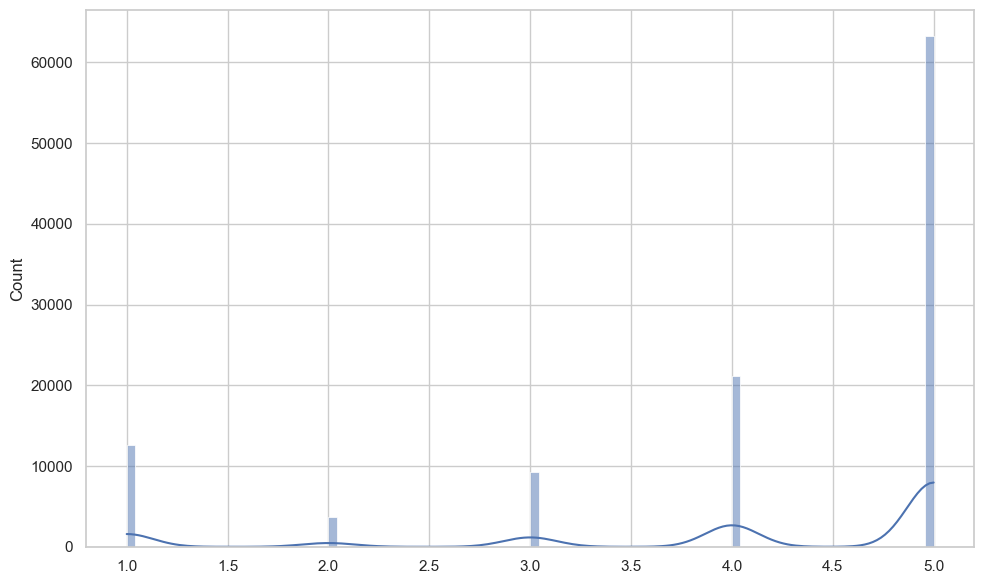

(<Figure size 1000x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [15]:
reviews_s_list = reviews.copy().tolist()

review_plot = Plotter()

review_plot.histogram(reviews_s_list)

In [16]:
feature_df = df.copy()

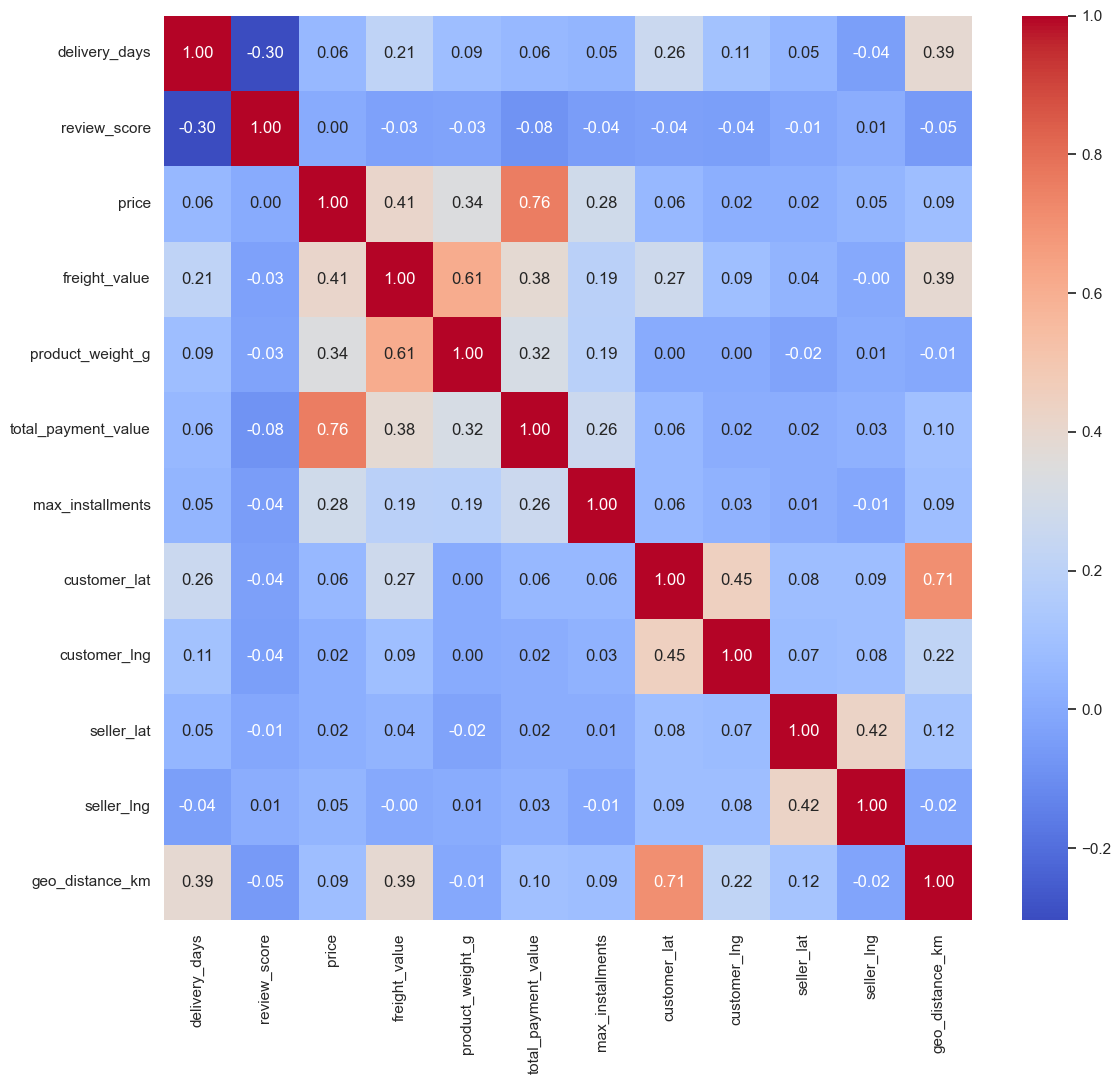

(<Figure size 1200x1100 with 2 Axes>, <Axes: >)

In [17]:
heatmap = Plotter()

heatmap.heatmap(data=feature_df)

In [57]:
deliveries_df = df.copy()[['order_purchase_timestamp', 'delivery_days']]

In [58]:
deliveries_df.head()

,order_purchase_timestamp,delivery_days
0,2018-01-11 15:30:49,6
1,2018-02-28 12:25:19,9
2,2018-02-03 09:56:22,13
3,2017-04-09 17:41:13,11
4,2018-02-10 10:59:03,18


In [61]:
deliveries_df.order_purchase_timestamp = pd.to_datetime(deliveries_df.order_purchase_timestamp)

In [64]:
deliveries_df['day_of_week'] = deliveries_df.order_purchase_timestamp.dt.day_name()
deliveries_df.head()

,order_purchase_timestamp,delivery_days,day_of_week
0,2018-01-11 15:30:49,6,Thursday
1,2018-02-28 12:25:19,9,Wednesday
2,2018-02-03 09:56:22,13,Saturday
3,2017-04-09 17:41:13,11,Sunday
4,2018-02-10 10:59:03,18,Saturday


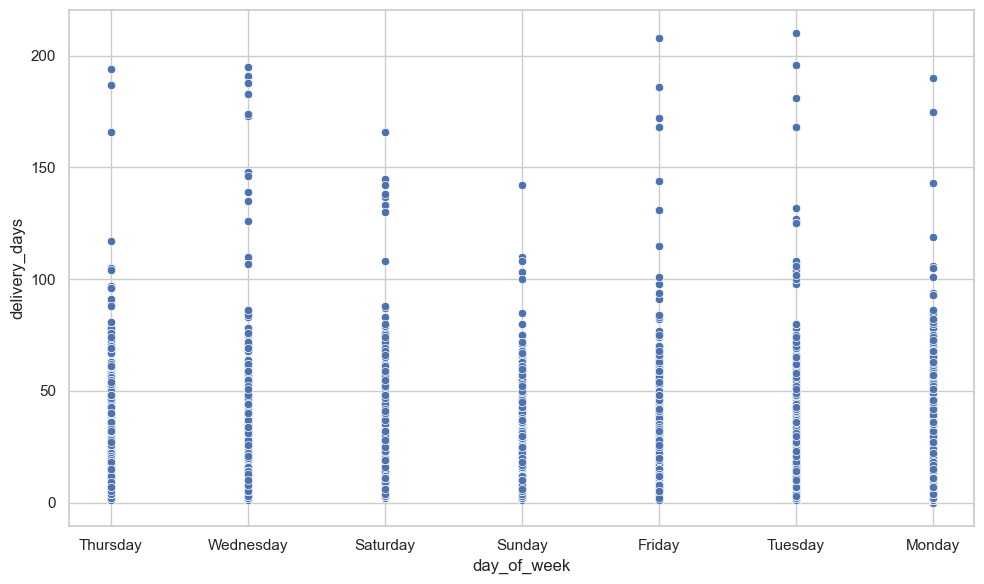

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='day_of_week', ylabel='delivery_days'>)

In [65]:
dow, dd = deliveries_df.copy()['day_of_week'], deliveries_df.copy().delivery_days
delivery_plot.scatter(x=dow, y=dd)

In [66]:
deliveries_df['hour_of_day'] = deliveries_df.order_purchase_timestamp.dt.hour
deliveries_df.head()

,order_purchase_timestamp,delivery_days,day_of_week,hour_of_day
0,2018-01-11 15:30:49,6,Thursday,15
1,2018-02-28 12:25:19,9,Wednesday,12
2,2018-02-03 09:56:22,13,Saturday,9
3,2017-04-09 17:41:13,11,Sunday,17
4,2018-02-10 10:59:03,18,Saturday,10


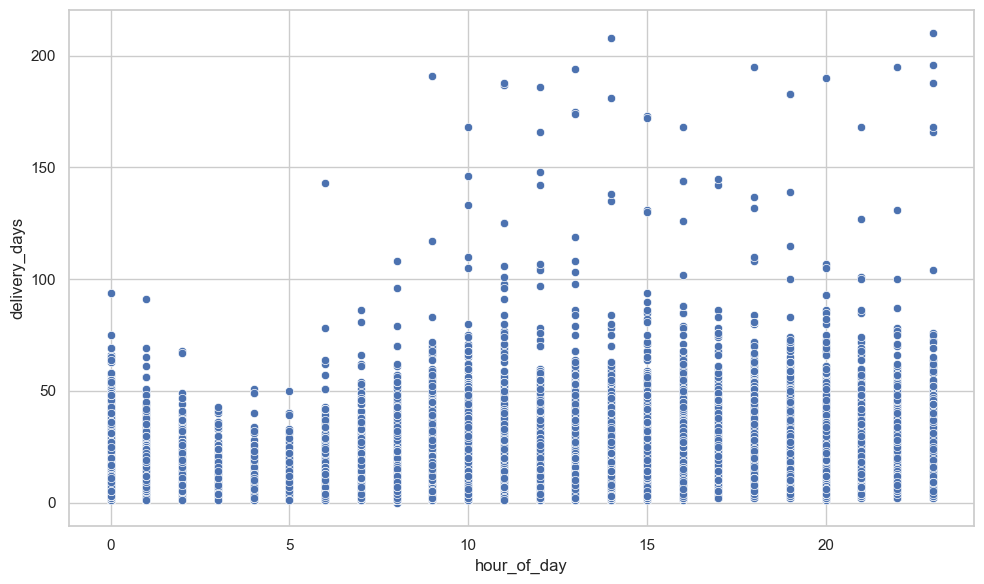

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='hour_of_day', ylabel='delivery_days'>)

In [67]:
hod, dd = deliveries_df.copy()['hour_of_day'], deliveries_df.copy().delivery_days
delivery_plot.scatter(x=hod, y=dd)